In [56]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE


df=pd.read_csv("fraud_detection_in _india.csv")
df




,transaction_id,customer_id,merchant_id,amount,transaction_time,is_fraudulent,card_type,location,purchase_category,customer_age,fraud_type
0,1.0,684415.0,2028.0,1262.770,11/24/2023 22:39,0.0,Rupay,Bangalore,NaN,28.0,Identity theft
1,2.0,447448.0,2046.0,2222.928,03/30/2024 16:18,0.0,MasterCard,Surat,POS,62.0,Malware
2,3.0,975001.0,2067.0,7509.832,03/07/2024 18:27,0.0,MasterCard,Hyderabad,POS,24.0,Malware
3,4.0,976547.0,NaN,2782.965,02/01/2024 00:58,0.0,Rupay,Hyderabad,Digital,62.0,Payment card fraud
4,5.0,935741.0,2044.0,NaN,12/22/2023 18:42,0.0,NaN,Bangalore,Digital,19.0,scam
...,...,...,...,...,...,...,...,...,...,...,...
7948,419.0,121982.0,2012.0,8843.820,01/14/2024 20:27,0.0,NaN,Delhi,Digital,22.0,phishing
7949,794.0,NaN,2007.0,NaN,12/11/2023 02:18,0.0,Rupay,Mumbai,Digital,19.0,Payment card fraud
7950,953.0,357278.0,2040.0,9506.530,01/14/2024 22:31,1.0,Rupay,Pune,Digital,23.0,Identity theft
7951,973.0,574839.0,2022.0,7292.241,02/28/2024 01:57,0.0,MasterCard,Surat,POS,32.0,scam


In [57]:
df.shape

(7953, 11)

In [58]:
df.dtypes

transaction_id       float64
customer_id          float64
merchant_id          float64
amount               float64
transaction_time      object
is_fraudulent        float64
card_type             object
location              object
purchase_category     object
customer_age         float64
fraud_type            object
dtype: object

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7953 entries, 0 to 7952
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     7478 non-null   float64
 1   customer_id        7532 non-null   float64
 2   merchant_id        7481 non-null   float64
 3   amount             7261 non-null   float64
 4   transaction_time   7385 non-null   object 
 5   is_fraudulent      7228 non-null   float64
 6   card_type          7386 non-null   object 
 7   location           7430 non-null   object 
 8   purchase_category  7421 non-null   object 
 9   customer_age       7285 non-null   float64
 10  fraud_type         7455 non-null   object 
dtypes: float64(6), object(5)
memory usage: 683.6+ KB


In [60]:
df.describe

<bound method NDFrame.describe of       transaction_id  customer_id  merchant_id    amount  transaction_time  \
0                1.0     684415.0       2028.0  1262.770  11/24/2023 22:39   
1                2.0     447448.0       2046.0  2222.928  03/30/2024 16:18   
2                3.0     975001.0       2067.0  7509.832  03/07/2024 18:27   
3                4.0     976547.0          NaN  2782.965  02/01/2024 00:58   
4                5.0     935741.0       2044.0       NaN  12/22/2023 18:42   
...              ...          ...          ...       ...               ...   
7948           419.0     121982.0       2012.0  8843.820  01/14/2024 20:27   
7949           794.0          NaN       2007.0       NaN  12/11/2023 02:18   
7950           953.0     357278.0       2040.0  9506.530  01/14/2024 22:31   
7951           973.0     574839.0       2022.0  7292.241  02/28/2024 01:57   
7952           770.0     425146.0       2059.0       NaN  02/26/2024 22:10   

      is_fraudulent   card_ty

In [61]:
df.isnull().sum()

transaction_id       475
customer_id          421
merchant_id          472
amount               692
transaction_time     568
is_fraudulent        725
card_type            567
location             523
purchase_category    532
customer_age         668
fraud_type           498
dtype: int64

In [62]:
df.columns

Index(['transaction_id', 'customer_id', 'merchant_id', 'amount',
       'transaction_time', 'is_fraudulent', 'card_type', 'location',
       'purchase_category', 'customer_age', 'fraud_type'],
      dtype='object')

In [63]:
df.duplicated().sum()

np.int64(6753)

In [64]:
df.drop_duplicates()

,transaction_id,customer_id,merchant_id,amount,transaction_time,is_fraudulent,card_type,location,purchase_category,customer_age,fraud_type
0,1.0,684415.0,2028.0,1262.770,11/24/2023 22:39,0.0,Rupay,Bangalore,NaN,28.0,Identity theft
1,2.0,447448.0,2046.0,2222.928,03/30/2024 16:18,0.0,MasterCard,Surat,POS,62.0,Malware
2,3.0,975001.0,2067.0,7509.832,03/07/2024 18:27,0.0,MasterCard,Hyderabad,POS,24.0,Malware
3,4.0,976547.0,NaN,2782.965,02/01/2024 00:58,0.0,Rupay,Hyderabad,Digital,62.0,Payment card fraud
4,5.0,935741.0,2044.0,NaN,12/22/2023 18:42,0.0,NaN,Bangalore,Digital,19.0,scam
...,...,...,...,...,...,...,...,...,...,...,...
1195,1196.0,460104.0,2001.0,8235.777,10/05/2023 15:05,NaN,MasterCard,Surat,POS,NaN,NaN
1196,1197.0,508874.0,2048.0,7146.615,03/13/2024 03:15,0.0,MasterCard,Pune,POS,65.0,Malware
1197,1198.0,175115.0,2076.0,625.550,02/15/2024 21:02,0.0,Visa,Jaipur,POS,42.0,Malware
1198,1199.0,119732.0,2003.0,14370.015,01/27/2024 23:25,0.0,MasterCard,Chennai,POS,24.0,Malware


Before cleaning:
 transaction_id        76
customer_id           68
merchant_id           67
amount               102
transaction_time      82
is_fraudulent        108
card_type             85
location              78
purchase_category     83
customer_age          97
fraud_type            78
dtype: int64

After cleaning:
 transaction_id       0
customer_id          0
merchant_id          0
amount               0
transaction_time     0
is_fraudulent        0
card_type            0
location             0
purchase_category    0
customer_age         0
fraud_type           0
dtype: int64

NaN in X: 75

Before SMOTE:
 is_fraudulent
0    553
1    258
Name: count, dtype: int64

After SMOTE:
 is_fraudulent
1    553
0    553
Name: count, dtype: int64

Confusion Matrix:
[[80 70]
 [36 33]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.53      0.60       150
           1       0.32      0.48      0.38        69

    accuracy           

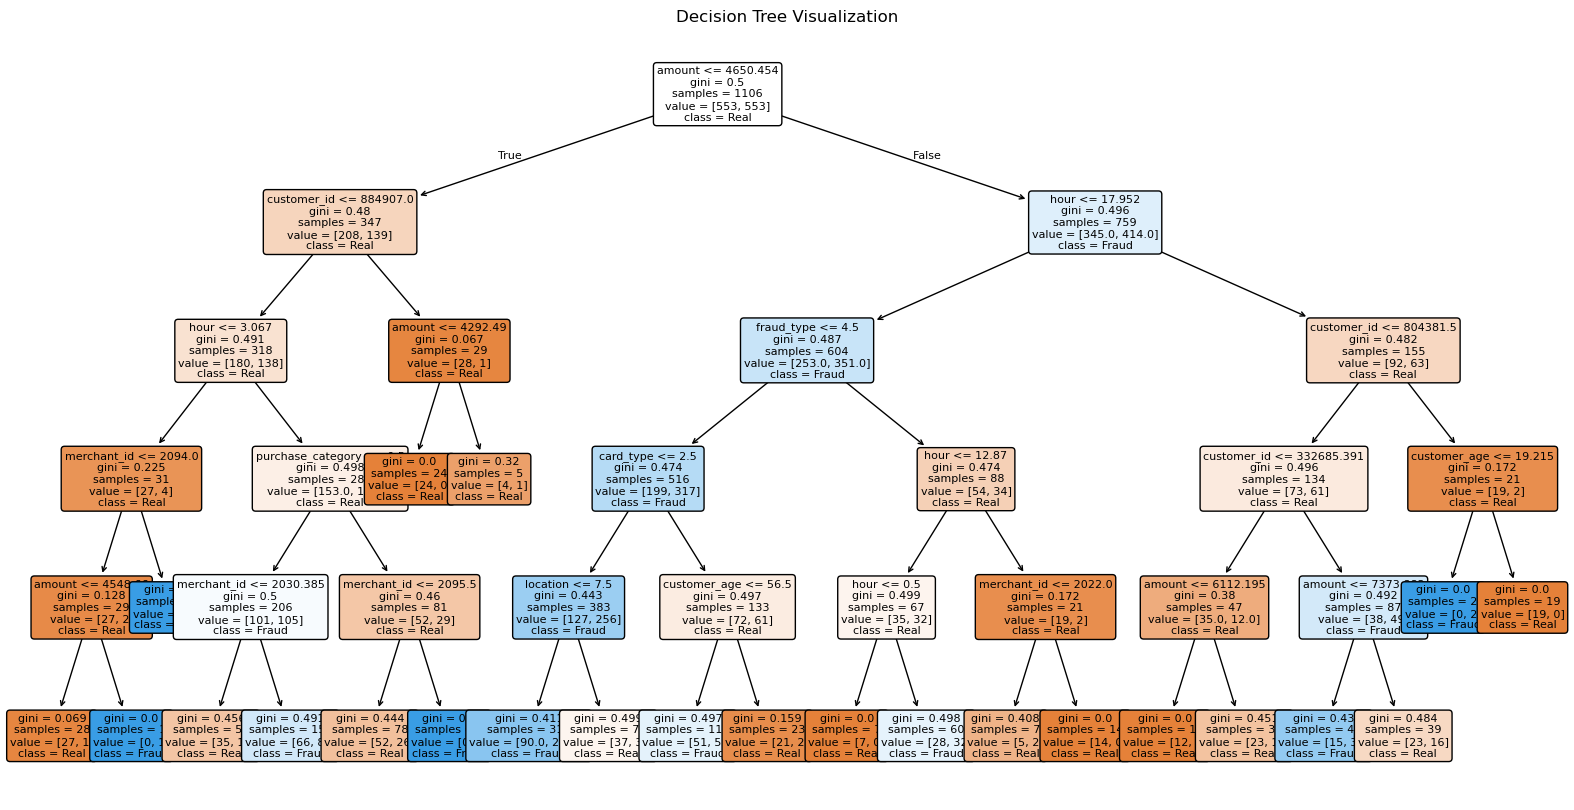

In [76]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE


df=pd.read_csv("fraud_detection_in _india.csv")
df

df = df.drop_duplicates()

print("Before cleaning:\n", df.isnull().sum())

# Replace infinite values
df = df.replace([np.inf, -np.inf], np.nan)

# Drop rows where target is missing
df = df.dropna(subset=['is_fraudulent'])

# Fill numeric columns
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna("Unknown")

# Convert target to int
df['is_fraudulent'] = df['is_fraudulent'].astype(int)

print("\nAfter cleaning:\n", df.isnull().sum())



df['transaction_time'] = pd.to_datetime(df['transaction_time'], errors='coerce')

# Extract hour
df['hour'] = df['transaction_time'].dt.hour

# Drop unnecessary columns
df = df.drop(['transaction_id', 'transaction_time'], axis=1, errors='ignore')



categorical_cols = df.select_dtypes(include='object').columns

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))


X = df.drop('is_fraudulent', axis=1)
y = df['is_fraudulent']


print("\nNaN in X:", X.isnull().sum().sum())



X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]



smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nBefore SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_res.value_counts())



model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

model.fit(X_train_res, y_train_res)

y_pred = model.predict(X_test)



print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



importances = pd.Series(model.feature_importances_, index=X.columns)
print("\nFeature Importance:\n")
print(importances.sort_values(ascending=False))



import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Real', 'Fraud'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Visualization")
plt.show()